# Solving Differential Equations with SciPy

**Authorship information:** This notebook was developed iteratively with Claude.ai, a large language model, for PHY 225 taught by Prof. Bryanne McDonough. The LLM was provided course context and a detailed outline and asked to flesh it out. Prof. McDonough reviewed and refined the content.

Both humans and LLMs can (and will) make mistakes. Please raise an issue on the upstream GitHub repository (the one you forked) if you find a problem.

## Grading

Note that for this assignment there are three parts. To achieve a good grade on this assignment, it is only necessary to complete parts 1 and 2 (on ODEs). However, to earn a score of 'Advanced', you must also complete Part 3 (on PDEs). If you find that Parts 1 and 2 take you a long time, it might be better to skip Part 3 and work on your projects instead.

Your assignment will be graded on the following scale:
- **No Evidence** — assignment not completed or submitted
- **Beginning** — some effort, but significant errors or omissions
- **Emerging** — mostly correct, but with some errors or omissions
- **Proficient** — correct and complete, with clear explanations (Parts 1 and 2 complete)
- **Advanced** — correct, complete, and demonstrates deeper understanding (Part 3 completed in addition to parts 1 and 2)


## Introduction: Tools for Solving Differential Equations

You have been introduced to `scipy.integrate.solve_ivp` for solving initial value problems (IVPs) and `scipy.integrate.solve_bvp` to solve boundary value problems (BVPs). You are strongly encouraged to refer to the official documentation whenever you are unsure about a function's arguments or return values:

- [`scipy.integrate.solve_ivp` documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html)
- [`scipy.integrate.solve_bvp` documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_bvp.html)

Before diving in, here are two techniques that will make these solvers far more powerful.

---

### Trick 1: Turning a system of equations into a single vector equation

Both `solve_ivp` and `solve_bvp` expect a single function that returns the derivatives of a **state vector** $\mathbf{u}$. This means that if you have a system of multiple equations — say, motion in both $x$ and $y$ — you can pack all the variables into one vector and return their derivatives together.

For example, suppose you have a function $f(t,x,y)$ that has two dependent variables ($x$ and $y$). Define the state vector:

$$
\mathbf{u} = \begin{pmatrix} x \\ y \end{pmatrix}
$$

Then the derivative function simply returns

$$
\frac{d\mathbf{u}}{dt} = \begin{pmatrix} \dot{x} \\ \dot{y} \end{pmatrix}
$$

where $\dot{x}$ and $\dot{y}$ are the time derivatives of $x$ and $y$ (which can themselves depend on the current state).

In Python, this looks like:

```python
def derivatives(t, u):
    x, y = u                  # unpack the state vector
    dxdt = ...                 # compute time derivative of x
    dydt = ...                 # compute time derivative of y
    return [dxdt, dydt]        # return du/dt as a list
```

---

### Trick 2: Reducing a higher-order ODE to a first-order system

Most ODE solvers — including `solve_ivp` — only work with first-order equations (equations involving at most a first derivative). If your equation involves a second derivative, you can always reduce it to a first-order system by introducing the first derivative as a new variable.

For example, consider Newton's second law:

$$
m\frac{d^2 x}{dt^2} = F(x, \dot{x}, t)
$$

Define $v = dx/dt$ (velocity). Then this single second-order equation becomes two first-order equations:

$$
\frac{dx}{dt} = v, \qquad \frac{dv}{dt} = \frac{F}{m}
$$

You can now pack $(x, v)$ into a state vector and apply Trick 1. In this assignment, you will use both tricks together.

---
## Part 1: Projectile Motion with Air Resistance

### Background

In introductory physics, projectile motion is solved by assuming the only force on a projectile is gravity. In reality, any object moving through air experiences a **drag force** that opposes its motion. For a dense spherical projectile (like a cannonball) moving at moderate speeds, the dominant drag contribution is **quadratic drag**, where the drag force is proportional to the square of the speed, and acts in the opposite direction:

$$
\mathbf{F}_{\rm drag} = -\frac{1}{2} C_d \rho_{\rm air} A |\mathbf{v}| \mathbf{v}
$$

where $C_d$ is the dimensionless drag coefficient (approximately $0.47$ for a sphere), $\rho_{\rm air}$ is the density of air, $A = \pi r^2$ is the cross-sectional area of the projectile, $|\mathbf{v}| = \sqrt{ \dot{x}^2 + \dot{y}^2}$ is the speed, and $\mathbf{v}$ is the velocity vector.

Applying Newton's second law in each direction, the equations of motion are:

$$
\ddot{x} = -\frac{C_d \rho_{\rm air} A}{2m}\sqrt{\dot{x}^2 + \dot{y}^2}\; \dot{x}
$$

$$
\ddot{y} = -g - \frac{C_d \rho_{\rm air} A}{2m}\sqrt{\dot{x}^2 + \dot{y}^2}\; \dot{y}
$$

Note here that we take the components of the drag force in each equation. Unlike the no-drag case, these equations have no closed-form analytic solution — we must solve them numerically.

Use the following parameter values throughout Part 1, except in Exercise 3, where you will be asked to vary the mass:

| Parameter | Symbol | Value |
|-----------|--------|-------|
| Gravitational acceleration | $g$ | $9.81\; \text{m/s}^2$ |
| Air density | $\rho_{\rm air}$ | $1.225\; \text{kg/m}^3$ |
| Drag coefficient (sphere) | $C_d$ | $0.47$ |
| Projectile radius | $r$ | $0.05\; \text{m}$ |
| Projectile mass | $m$ | $1\; \text{kg}$ |
| Launch speed | $v_0$ | $50\; \text{m/s}$ |
| Launch angle | $\theta$ | $45°$ |

### Exercise 1: Setting Up the ODE System

Using Trick 2 (reduce second-order to first-order) and then Trick 1 (pack into a state vector), convert the two second-order equations above into a system of four first-order ODEs.

Define the state vector as $\mathbf{u} = (x,\, y,\, v_x,\, v_y)$.

In the code cell below, define:
1. The physical constants listed in the table above
2. The initial conditions: the projectile starts at the origin $(x_0, y_0) = (0, 0)$ with velocity components $(v_{x,0}, v_{y,0}) = (v_0 \cos\theta,\, v_0 \sin\theta)$
3. A function `derivatives(t, u)` that takes the current time `t` and state vector `u`, and returns $d\mathbf{u}/dt$ as a list of four values

You will also need to **stop the integration when the projectile hits the ground** ($y = 0$ after launch). The cell below defines an event function that `solve_ivp` can use to detect this — read the `solve_ivp` documentation to understand how the `events` argument works.

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [19]:
# define physical constants and initial conditions
x0 = 0
y0 = 0
v0= 50 #m/s
theta = 45 #degrees
Cd = .47
pair = 1.225 #kg/m^3
radius = .05
mass = 1
area = np.pi * radius**2
u = x, y, vx, vy = 0, 0, v0 * np.cos(np.radians(theta)), v0 * np.sin(np.radians(theta))

In [20]:
# define the derivatives function: takes (t, u) and returns du/dt
def derivatives(t, u):
    x, y, vx, vy = u
    speed = np.sqrt(vx**2 + vy**2)
    drag_force = 0.5 * Cd * pair * area * speed**2
    k = (Cd * pair * area) / (2 * mass)
    ax = -k * speed * vx
    ay = -k * speed * vy - 9.81
    dxdt = vx
    dydt = vy
    dvxdt = ax
    dvydt = ay
    return [dxdt, dydt, dvxdt, dvydt]

In [21]:
# event function: solve_ivp will stop integration when this returns 0
def ground_hit(t, u):
    return u[1]   # y-coordinate; root occurs when y = 0


# set properties for this function that solve_ivp will read
ground_hit.terminal = True    # stop integration when event is found
ground_hit.direction = -1     # only trigger on downward crossing (y going from + to -)

### Exercise 2: Solving and Plotting the Trajectory

Use `solve_ivp` to integrate the equations of motion from $t = 0$ to a maximum of $t = 30\;\text{s}$ (the event function above will stop it earlier once the projectile lands). Pass your `ground_hit` event function using the `events` keyword argument.

You'll want to review the documentation to understand the output of the `solve_ivp` function, which includes the time points and the corresponding state vectors at those points.

Then make a figure that plots the $x$–$y$ trajectory of the projectile with drag, overlaid with the trajectory that would result with *no* drag (use the analytic parabola: $x(t) = v_{x,0}\,t$, $y(t) = v_{y,0}\,t - \frac{1}{2}g t^2$). Label both curves.

Make sure all axes are labeled with units.

In [23]:
# solve the IVP with the ground_hit event
sol = solve_ivp(
    derivatives,
    t_span=(0, 30),  # time from 0 to 30 seconds
    y0=u,
    events=ground_hit,
    max_step=0.01  # limit max step size for better accuracy
)
t_data = sol.t
x_data = sol.y[0]
y_data = sol.y[1]

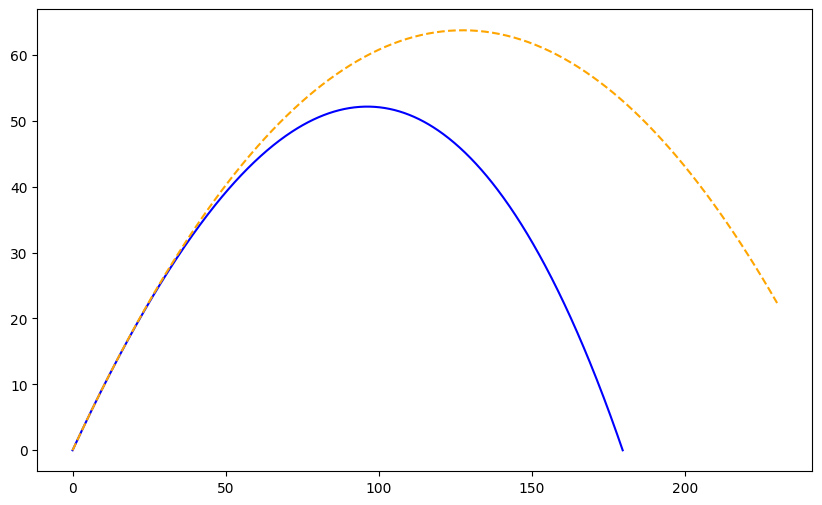

In [30]:
# plot the trajectory with and without drag 
plt.figure(figsize=(10, 6))
plt.plot(x_data, y_data, label='With Drag', color='blue')

#no drag trajectory
vx0= sol.y[2][0]
vy0= sol.y[3][0]
t_analytic = np.linspace(0, max(t_data), 100)
x_no_drag = vx0 * t_analytic
y_no_drag = vy0 * t_analytic - 0.5 * 9.81 * t_analytic**2

plt.plot(x_no_drag, y_no_drag, label='No Drag', color='orange', linestyle='--')

### Exercise 3: Effect of Projectile Mass

Without considering air resistance, the trajectory of a projectile depends only on its initial velocity and launch angle. Notice that the drag-to-gravity ratio depends on mass: a heavier projectile of the same size is affected less by drag (this is why a shot put travels much farther than a ping-pong ball launched at the same speed).

Solve the trajectory for projectile masses of $m = 0.1,\; 0.5,\; 1,\; 5,\; 50\;\text{kg}$, keeping all other parameters the same (same radius, same launch conditions). Plot all five trajectories on a single figure, labeling each curve with its mass. Also plot the no-drag parabola as a reference.

> **Note:** When the mass changes, the drag coefficient $b = C_d \rho_{\rm air} A / (2m)$ changes. Make sure your `derivatives` function uses the current mass.

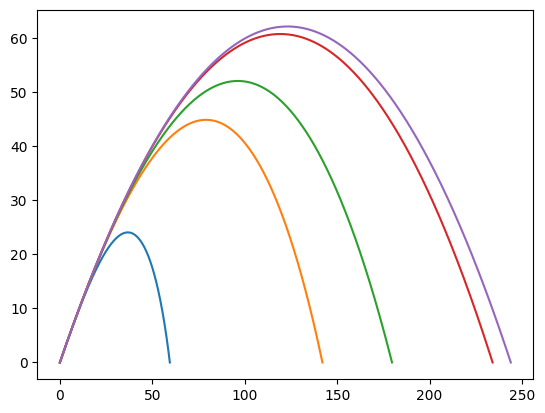

In [31]:
# solve and plot trajectories for multiple masses
for mass in [0.1, 0.5, 1, 5, 10]:  # different masses
    k = (Cd * pair * area) / (2 * mass)
    
    def derivatives_mass(t, u):
        x, y, vx, vy = u
        speed = np.sqrt(vx**2 + vy**2)
        ax = -k * speed * vx
        ay = -k * speed * vy - 9.81
        return [vx, vy, ax, ay]
    
    sol_mass = solve_ivp(
        derivatives_mass,
        t_span=(0, 30),
        y0=u,
        events=ground_hit,
        max_step=0.01
    )
    plt.plot(sol_mass.y[0], sol_mass.y[1], label=f'Mass={mass}kg')

---
## Part 2: Steady-State Temperature in a Heat Pin

### Background

Electronic components generate heat that must be dissipated to prevent damage. One common solution is a **heat pin** (or heat fin): a metal rod attached to a hot component at one end, with the other end exposed to cooler surroundings. Heat flows along the rod by conduction, and the goal is to understand how the temperature varies along its length.

When the system has reached thermal equilibrium (the steady state), the temperature $T(x)$ along a 1D rod of length $L$ satisfies:

$$
\frac{d^2 T}{dx^2} = 0
$$

with fixed temperatures at the Left and Right ends:

$$
T(0) = T_L, \qquad T(L) = T_R
$$

This is a **boundary value problem** (BVP): the solution is constrained at two different spatial locations, not at a single starting point. This is fundamentally different from the IVP in Part 1, where all constraints were given at $t = 0$. The `scipy.integrate.solve_bvp` solver is designed for this class of problem.

The analytic solution to this particular BVP is simply the linear temperature profile:

$$
T(x) = T_L + \frac{T_R - T_L}{L}\, x
$$

You will use this as a check on your numerical solution.

Use the following values: $L = 0.10\;\text{m}$, $T_L = 100\;°\text{C}$, $T_R = 20\;°\text{C}$.

---

### How `solve_bvp` Works

`solve_bvp` solves a BVP of the form:

$$
\frac{d\mathbf{Y}}{dx} = \mathbf{f}(x, \mathbf{Y})
$$

subject to boundary conditions specified by a function `bc(Ya, Yb)` that returns zero when the BCs are satisfied. Here `Ya` and `Yb` are the values of $\mathbf{Y}$ at the left and right boundaries, respectively.

To use Trick 2 on our second-order equation, define $\mathbf{Y} = (T, T')$ where $T' = dT/dx$. Then:

$$
\frac{d}{dx}\begin{pmatrix} T \\ T' \end{pmatrix} = \begin{pmatrix} T' \\ 0 \end{pmatrix}
$$

The boundary conditions $T(0) = T_L$ and $T(L) = T_R$ translate to:

```python
def bc(Ya, Yb):
    return [Ya[0] - T_L,   # T at x=0 must equal T_L
            Yb[0] - T_R]   # T at x=L must equal T_R
```

`solve_bvp` also requires an initial guess for the solution on an initial mesh (a mesh is essentially the grid spacing you define, the points you are evaluating at). A reasonable starting guess is a zero array — the solver will iterate from there.

Refer to the [`solve_bvp` documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_bvp.html) for details on the return value and how to evaluate the solution on a fine grid.

### Exercise 4: Setting Up and Solving the BVP

Using the structure described above:

1. Define the problem parameters ($L$, $T_L$, $T_R$)
2. Write the function `ode_fun(x, Y)` that returns $d\mathbf{Y}/dx$
3. Write the function `bc(Ya, Yb)` that encodes the boundary conditions
4. Create an initial mesh `x_mesh = np.linspace(0, L, 50)` and a zero initial guess `Y_guess = np.zeros((2, x_mesh.size))`
5. Call `solve_bvp` and check that the solution converged (inspect the `status` and `message` fields of the result)

In [32]:
from scipy.integrate import solve_bvp

In [ ]:
# define parameters, ode_fun, and bc
L = .1
TL = 100
TR = 20

def ode_fun(x, T):
    

In [ ]:
# set up initial mesh and guess, then call solve_bvp


### Exercise 5: Plotting and Validation

Evaluate the numerical solution on a fine grid using `sol.sol(x_fine)[0]`, where `x_fine = np.linspace(0, L, 500)` and `sol` is the result from `solve_bvp`.

Make a plot showing:
- The numerical solution as a solid line
- The analytic solution $T(x) = T_L + (T_R - T_L)\, x / L$ as a dashed line

Also compute and print the maximum absolute difference between the two solutions across all grid points. This is the numerical residual — how well does your solver match the analytic result?

In [ ]:
# evaluate solution on fine grid, plot vs analytic solution, print max residual


---
## (Advanced) Part 3: The Time-Dependent Heat Equation

Note that you do not need to complete this part to earn a good score on the assignment, but it is necessary to earn a score of 'Advanced'. It is a good exercise, but if the previous parts took you a long time, it might be better to skip this part and work on your projects.

### Background

The steady-state solution in Part 2 tells us what the temperature looks like *after* the rod has reached equilibrium — but it says nothing about *how* it gets there. To understand the time evolution, we need the **heat equation**, a partial differential equation (PDE) that describes how temperature evolves in both space and time:

$$
\frac{\partial T}{\partial t} = \alpha \frac{\partial^2 T}{\partial x^2}
$$

The constant $\alpha$ is the **thermal diffusivity** of the rod material (units of m²/s). A large $\alpha$ means heat diffuses quickly. For copper, $\alpha \approx 1.17 \times 10^{-4}\;\text{m}^2/\text{s}$.

---

### Turning the PDE into a System of ODEs

To solve this PDE numerically, we will use a technique called the **method of lines**. The idea is to discretize space — divide the rod into $N$ equally spaced grid points — while leaving time continuous. This converts the PDE into a system of ODEs in time, one for each interior grid point, which we can then hand to `solve_ivp`.

**Step 1: Discretize space.** Divide $[0, L]$ into $N$ intervals with spacing $\Delta x = L/N$, giving grid points $x_i = i\,\Delta x$ for $i = 0, 1, \ldots, N$.

**Step 2: Approximate the spatial second derivative.** At each interior grid point $x_i$, we approximate $\partial^2 T / \partial x^2$ using the **centered finite difference**:

$$
\frac{\partial^2 T}{\partial x^2}\bigg|_{x_i} \approx \frac{T_{i+1} - 2T_i + T_{i-1}}{(\Delta x)^2}
$$

This approximation comes from combining two Taylor expansions (one for the step forward and one for the step backward): $T(x \pm \Delta x) = T(x) \pm \Delta x\, T' + \frac{(\Delta x)^2}{2}T'' + \ldots$. Adding the two expressions and solving for $T''$ gives the formula above.

**Step 3: Apply the boundary conditions.** The boundary temperatures $T_0 = T_L$ and $T_N = T_R$ are fixed at all times — only the $N-1$ interior values $T_1, \ldots, T_{N-1}$ evolve in time.

**Step 4: Write the system of ODEs.** Substituting the finite difference into the heat equation:

$$
\frac{dT_i}{dt} = \alpha\,\frac{T_{i+1} - 2T_i + T_{i-1}}{(\Delta x)^2}, \qquad i = 1, \ldots, N-1
$$

This is now a system of $N-1$ ordinary differential equations — one per interior grid point — which `solve_ivp` can solve.

> **A note on time-step stability:** If you were stepping time forward manually (with a fixed $\Delta t$), the FTCS (Forward-Time Centered-Space) scheme is only stable when $\alpha\,\Delta t / (\Delta x)^2 \leq 0.5$. Because `solve_ivp` uses an adaptive time-stepper, it handles this automatically — but you may find it helpful to set a `max_step` to guide the solver on very fine grids.

### Exercise 6: Implementing the Spatial Discretization

Set up the spatial grid and define the ODE system for `solve_ivp`.

1. Define $N = 50$ interior points (so the rod is divided into 51 intervals), along with $\Delta x$, $\alpha$, and all boundary/rod parameters from Part 2.
2. Write a function `heat_ode(t, T_interior)` that takes the current time and the values of $T$ at the $N-1$ interior grid points, and returns $dT_i/dt$ for each interior point. Your function will need to **prepend $T_L$ and append $T_R$** to the interior array before computing the finite differences, so that the boundary values are available for the stencil at $i = 1$ and $i = N-1$.

> **Hint:** If `T_all` is a length-$(N+1)$ array with boundary values included, the centered finite difference for all interior points at once is:
> ```python
> (T_all[2:] - 2*T_all[1:-1] + T_all[:-2]) / dx**2
> ```

In [ ]:
# set up spatial grid and define heat_ode(t, T_interior)


### Exercise 7: Solving and Visualizing the Time Evolution

Use `solve_ivp` to solve the heat equation over the time interval $t \in [0, 300]$ seconds.

Use the following initial condition: the rod starts at a **uniform temperature of $20\;°\text{C}$** everywhere (except at the boundaries, which are immediately set to $T_L = 100\;°\text{C}$ and $T_R = 20\;°\text{C}$).

To get output at specific times, pass the keyword argument `t_eval=np.array([0, 5, 20, 60, 150, 300])` to `solve_ivp`.

Plot all six temperature profiles on the same axes, with each curve labeled by its time. Include the boundary points ($x = 0$ and $x = L$) in your plot — remember to prepend $T_L$ and append $T_R$ to the interior solution arrays before plotting.

> **Tip:** If your solution looks strange or diverges, check that your `heat_ode` function correctly handles the boundary values and that $\Delta x$ is computed correctly.

In [ ]:
# set up initial conditions and solve the heat equation


In [ ]:
# plot temperature profiles at each output time


### Exercise 8: Comparison to the Steady-State Solution

The heat equation should approach the steady-state solution from Part 2 at long times.

On a new figure, plot:
- The temperature profile from your final time step ($t = 300\;\text{s}$) from Exercise 7
- The analytic steady-state solution $T(x) = T_L + (T_R - T_L)\,x/L$ from Part 2

Print the maximum absolute difference between the two profiles. 

In [ ]:
# compare final time step to the Part 2 steady-state solution


---
### Extensions

These exercises are not required, but they are a good way to deepen your understanding.

- **Part 1:** Add a horizontal wind of $w = 5\;\text{m/s}$ (in the $+x$ direction) to the drag calculation by replacing $v_x$ with $(v_x - w)$ in the drag terms. Re-run Exercise 3 and compare the mass-dependent trajectories with and without wind.
- **Part 2:** Extend the BVP to include surface cooling (the **fin equation**): $d^2T/dx^2 = m^2(T - T_{\rm env})$, where $m^2 = hP/(kA)$ ($h = 10\;\text{W m}^{-2}\text{K}^{-1}$, $P = 2\pi r$ for a rod of radius $r = 0.005\;\text{m}$, $k = 400\;\text{W m}^{-1}\text{K}^{-1}$ for copper, $A = \pi r^2$, $T_{\rm env} = 20\;°\text{C}$). Solve and plot the non-linear temperature profile, and compare to the simple BVP from Exercise 4.
- **Part 3:** Try a different initial condition — for example, a Gaussian temperature spike at the center of the rod: $T(x, 0) = T_R + (T_{\rm peak} - T_R)\,\exp[-(x - L/2)^2 / (2\sigma^2)]$ with $T_{\rm peak} = 150\;°\text{C}$ and $\sigma = 0.01\;\text{m}$. How does the spike evolve? Does the system still approach the same steady state?

## LLM Disclosure

In lieu of the reflection on Moodle, please edit this cell (double-click on it) to disclose how (if at all) you used LLMs to help with these exercises. Specify which models you used and what you used them for.


< your disclosure >
